In [1]:
IMAGE_SIZES = [32, 64, 128, 224] # los tamaños de imagen siempre son 1:1 asi que no hace falta diferenciar entre width y height
BEST_BATCH_SIZE = 8 # numero de elementos procesados conjuntamente en cada iteracion
EPOCHS = 50 # numero de epocas para entrenamiento

In [3]:
##%%capture
#%tensorflow_version 2.x
!pip install tensorflow==2.9.2
import tensorflow as tf
import numpy as np
import os, subprocess, pathlib, time
from google.colab import drive
import matplotlib.pyplot as plt

import tensorflow.keras.layers as layers
import tensorflow.keras.models as models
import tensorflow.keras.optimizers as optimizers


In [4]:
!python --version                     # mostrar version de python
print('Tensorflow ' + tf.__version__) # mostrar version tensorflow


# Montar Google Drive y crear carpetas
drive.mount('/content/gdrive', force_remount=True)

work_dir = '/content/work_dir'                    # directorio de trabajo en local (mas rapido)
dwld_dir = '/content/gdrive/My Drive/dwld_dir'    # directorio de descarga en Google drive personal
subprocess.call(["mkdir","-p",work_dir])          # crear directorio para trabajo
subprocess.call(["mkdir","-p",dwld_dir+'/dataset/'])  # crear directorio para dataset

os.chdir(dwld_dir+'/dataset/')                        # posicionarse en el directorio
# Descargar dataset scenes15 si no esta disponible
if os.path.isfile('./dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/tsv/dataset_scenes15.zip

# Copiar el dataset al directorio local (mayor velocidad de lectura que en Gdrive)
!cp /content/gdrive/My\ Drive/dwld_dir/dataset/dataset_scenes15.zip /content/work_dir/

os.chdir(work_dir)                        # posicionarse en el directorio
if os.path.isdir('./scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

print('El dataset se encuentra descargado en el directorio {} \ny descomprimido en el directorio {} (usado para lectura de datos)'.format(dwld_dir, work_dir))

Python 3.10.12
Tensorflow 2.9.2
Mounted at /content/gdrive
El dataset se encuentra descargado en el directorio /content/gdrive/My Drive/dwld_dir 
y descomprimido en el directorio /content/work_dir (usado para lectura de datos)


In [5]:
dataset_dir = pathlib.Path(work_dir + '/scenes15/')

# Obtener etiquetas de clase y numero de clases
CLASS_NAMES = np.array([item.name for item in dataset_dir.glob('*')]) #clases son subdirectorios de '/train/'
NUM_CLASSES = len(CLASS_NAMES) # numero total de clases

In [6]:
def generator_dataset(BATCH_SIZE = 16, IMG_HEIGHT = 32, IMG_WIDTH = 32, IMG_CHANNELS = 3):
  # Crear ImageDataGenerator convirtiendo de uint8 a float32 en el rango [0,1].
  img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.20)

  # Obtenemos un iterador sobre los datos de entrenamiento del dataset
  # aplicando el ImageDataGenerator creado anteriormente

  train_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                            target_size=(IMG_HEIGHT, IMG_WIDTH),
                                            color_mode='rgb',
                                            classes = list(CLASS_NAMES),
                                            class_mode='categorical',
                                            batch_size=BATCH_SIZE,
                                            subset="training",
                                            shuffle=True,
                                            seed=0)

  test_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                            target_size=(IMG_HEIGHT, IMG_WIDTH),
                                            color_mode='rgb',
                                            classes = list(CLASS_NAMES),
                                            class_mode='categorical',
                                            batch_size=BATCH_SIZE,
                                            subset="validation",
                                            shuffle=True,
                                            seed=0)

  return train_data_gen, test_data_gen


In [7]:
def model_creation(IMG_HEIGHT = 32, IMG_WIDTH = 32, IMG_CHANNELS = 3, print_summary = False):
  # definir modelo de red
  model = models.Sequential()

  # incluir capa convolucional C1
  model.add(layers.Conv2D(filters=6,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation='relu',
                          input_shape=(IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)))

  # incluir average pooling S2
  model.add(layers.AveragePooling2D())

  # incluir capa convolucional C3
  model.add(layers.Conv2D(filters=16,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation='relu'))

  # incluir average pooling S4
  model.add(layers.AveragePooling2D())

  # convertir el volumen de datos en vector fila para conectarlo con capa FC
  model.add(layers.Flatten())

  # incluir fully convolutional F5
  model.add(layers.Dense(units=120, activation='relu'))

  # incluir fully convolutional F6
  model.add(layers.Dense(units=84, activation='relu'))

  # incluir salida OUTPUT
  model.add(layers.Dense(units=NUM_CLASSES, activation = 'softmax'))


  # mostar resumen
  if print_summary == True:
    model.summary()


  # definicion con optimizador con valores definidos por el usuario
  LEARNING_RATE = 0.01 # factor de aprendizaje
  model.compile(optimizer=optimizers.SGD(lr=LEARNING_RATE),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

  return model

Ejecución

In [8]:
IMG_CHANNELS = 3

test_loss_list = []
test_acc_list = []

train_loss_list = []
train_acc_list = []

test_loss_list = []
test_acc_list = []

train_loss_list = []
train_acc_list = []

history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []

for image_size in IMAGE_SIZES:
  print(f"{'='*10} INICIANDO IMAGE_SIZE {image_size} {'='*10}")

  model = model_creation(IMG_HEIGHT = image_size, IMG_WIDTH = image_size, IMG_CHANNELS = IMG_CHANNELS, print_summary = False)
  train_data_gen, test_data_gen = generator_dataset(BATCH_SIZE = BEST_BATCH_SIZE, IMG_HEIGHT = image_size, IMG_WIDTH = image_size, IMG_CHANNELS = IMG_CHANNELS)

  with tf.device('/GPU:0'):
    history = model.fit_generator(
        generator=train_data_gen,
        steps_per_epoch=train_data_gen.n // BEST_BATCH_SIZE,
        validation_data=test_data_gen,
        validation_steps=test_data_gen.n // BEST_BATCH_SIZE,
        epochs=EPOCHS,
        verbose=1
    )





    test_loss, test_acc = model.evaluate_generator( generator=test_data_gen,
                                                    steps = test_data_gen.n // BEST_BATCH_SIZE,
                                                    verbose=1)

    train_loss, train_acc = model.evaluate_generator( generator=train_data_gen,
                                                    steps = train_data_gen.n // BEST_BATCH_SIZE,
                                                    verbose=1)


  test_loss_list.append(test_loss)
  test_acc_list.append(test_acc)

  train_loss_list.append(train_loss)
  train_acc_list.append(train_acc)

  history_acc_list.append(history.history['accuracy']         )
  history_val_acc_list.append(history.history['val_accuracy'] )

  # funcion de perdidas
  history_loss_list.append(history.history['loss']            )
  history_val_loss_list.append(history.history['val_loss']    )




print("test_loss_list: ", test_loss_list)
print("test_acc_list: ", test_acc_list)

print("train_loss_list: ", train_loss_list)
print("train_acc_list: ", train_acc_list)

========== INICIANDO IMAGE_SIZE 32 ==========


/usr/local/lib/python3.10/dist-packages/keras/optimizers/optimizer_v2/gradient_descent.py:108: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(SGD, self).__init__(name, **kwargs)
<ipython-input-8-2b652310b2e4>:27: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/50
449/449 [==============================] - 11s 21ms/step - loss: 2.6929 - accuracy: 0.0869 - val_loss: 2.6868 - val_accuracy: 0.0957
Epoch 2/50
449/449 [==============================] - 10s 22ms/step - loss: 2.6659 - accuracy: 0.1005 - val_loss: 2.6640 - val_accuracy: 0.1126
Epoch 3/50
449/449 [==============================] - 9s 20ms/step - loss: 2.5993 - accuracy: 0.1317 - val_loss: 2.5897 - val_accuracy: 0.1498
Epoch 4/50
449/449 [==============================] - 8s 19ms/step - loss: 2.5166 - accuracy: 0.1726 - val_loss: 2.5529 - val_accuracy: 0.1689
Epoch 5/50
449/449 [==============================] - 10s 22ms/step - loss: 2.4503 - accuracy: 0.1977 - val_loss: 2.5298 - val_accuracy: 0.1971
Epoch 6/50
449/449 [==============================] - 9s 20ms/step - loss: 2.3937 - accuracy: 0.2238 - val_loss: 2.4848 - val_accuracy: 0.2038
Epoch 7/50
449/449 [==============================] - 

<ipython-input-8-2b652310b2e4>:40: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  test_loss, test_acc = model.evaluate_generator( generator=test_data_gen,


  4/449 [..............................] - ETA: 8s - loss: 0.1714 - accuracy: 0.9375 

<ipython-input-8-2b652310b2e4>:44: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  train_loss, train_acc = model.evaluate_generator( generator=train_data_gen,


449/449 [==============================] - 7s 16ms/step - loss: 0.1434 - accuracy: 0.9546
========== INICIANDO IMAGE_SIZE 64 ==========
Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/50
449/449 [==============================] - 18s 38ms/step - loss: 2.6819 - accuracy: 0.0935 - val_loss: 2.6352 - val_accuracy: 0.1059
Epoch 2/50
449/449 [==============================] - 17s 37ms/step - loss: 2.5386 - accuracy: 0.1626 - val_loss: 2.6023 - val_accuracy: 0.1622
Epoch 3/50
449/449 [==============================] - 18s 39ms/step - loss: 2.3768 - accuracy: 0.2222 - val_loss: 2.4257 - val_accuracy: 0.1824
Epoch 4/50
449/449 [==============================] - 17s 37ms/step - loss: 2.2645 - accuracy: 0.2572 - val_loss: 2.3676 - val_accuracy: 0.2579
Epoch 5/50
449/449 [==============================] - 17s 38ms/step - loss: 2.1569 - accuracy: 0.2890 - val_loss: 2.2846 - val_accuracy: 0.2477
Epoch 6/50
449/449 [==============================] - 17s 3

Plotting resultados

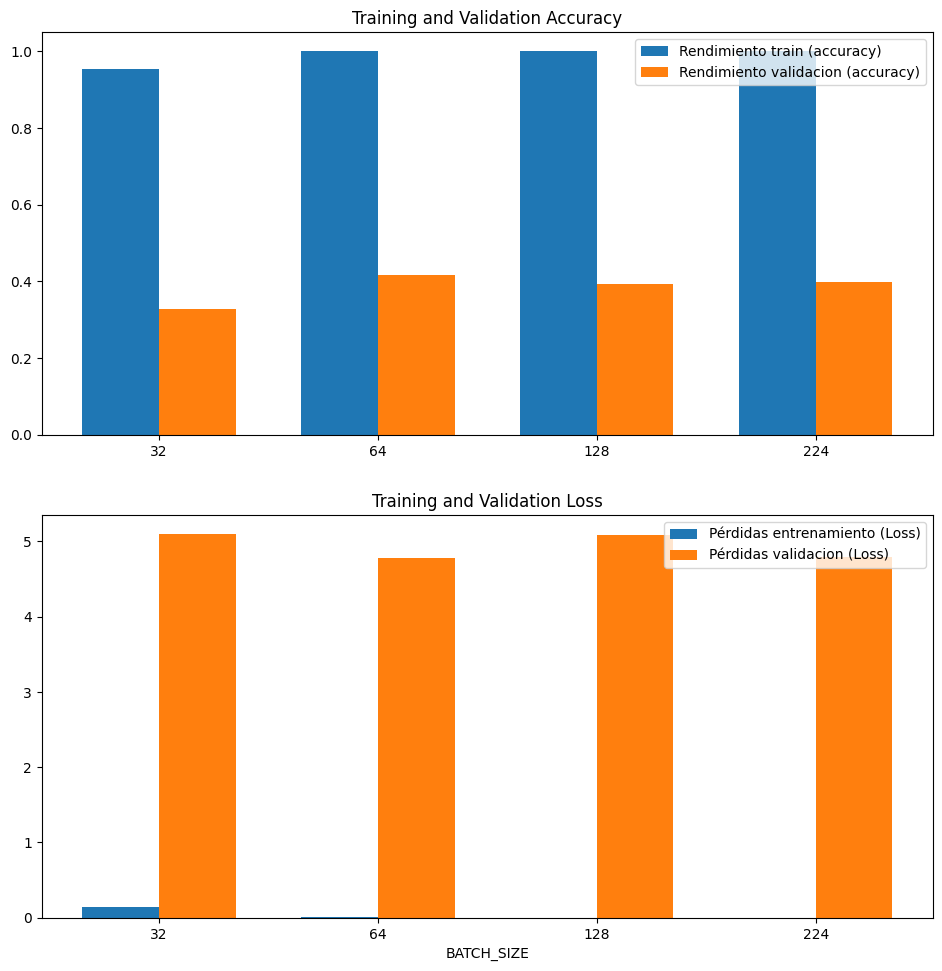

In [9]:
"""
history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []
"""

ind = np.arange(len(IMAGE_SIZES))
width = 0.35

fig, axs = plt.subplots(2,1)
axs[0].bar(ind, train_acc_list,width,  label='Rendimiento train (accuracy)')
axs[0].bar(ind + width, test_acc_list,width,  label='Rendimiento validacion (accuracy)')
axs[0].legend(loc='upper right')
axs[0].set_title('Training and Validation Accuracy')

axs[0].set_xticks(ind + width / 2)
axs[0].set_xticklabels(IMAGE_SIZES)




axs[1].bar(ind, train_loss_list,width,  label='Pérdidas entrenamiento (Loss)')
axs[1].bar(ind + width, test_loss_list,width,  label='Pérdidas validacion (Loss)')
axs[1].legend(loc='upper right')
axs[1].set_title('Training and Validation Loss')

axs[1].set_xticks(ind + width / 2)
axs[1].set_xticklabels(IMAGE_SIZES)
axs[1].set_xlabel('BATCH_SIZE')


fig.set_size_inches(11.5, 11.5)
fig.set_dpi(100)
plt.show()

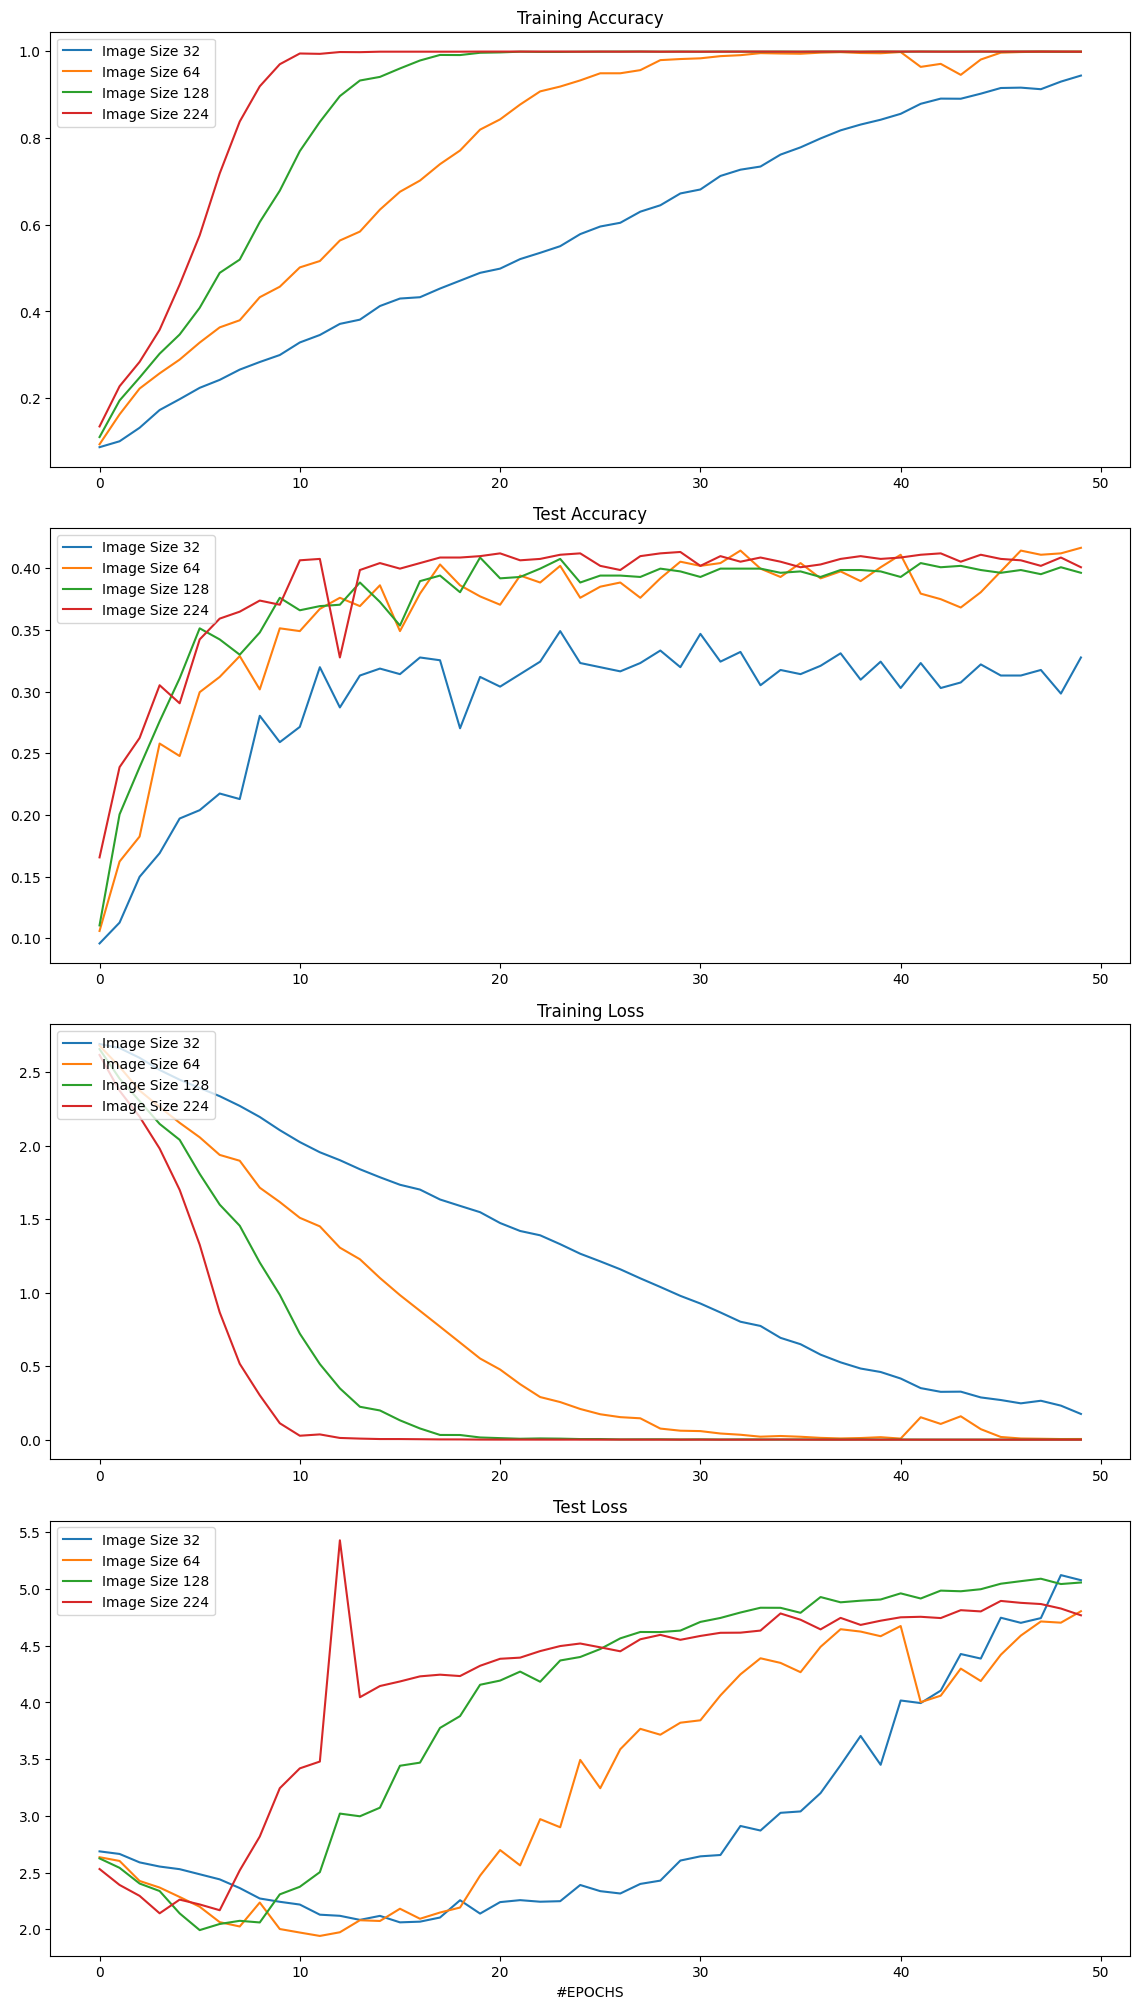

In [10]:
"""test_loss_list = []
test_acc_list = []

train_loss_list = []
train_acc_list = []

history_acc_list = []
history_val_acc_list = []
history_loss_list = []
history_val_loss_list = []
"""

fig, axs = plt.subplots(4,1)
epoch_list = np.arange(EPOCHS)

for idx, batch_size in enumerate(IMAGE_SIZES):
  axs[0].plot(epoch_list, history_acc_list[idx],  label=f'Image Size {batch_size}')
  axs[0].set_title(f'Training Accuracy')
  axs[0].legend(loc='upper left')

for idx, batch_size in enumerate(IMAGE_SIZES):
  axs[1].plot(epoch_list, history_val_acc_list[idx],  label=f'Image Size {batch_size}')
  axs[1].set_title(f'Test Accuracy')
  axs[1].legend(loc='upper left')


for idx, batch_size in enumerate(IMAGE_SIZES):
  axs[2].plot(epoch_list, history_loss_list[idx],  label=f'Image Size {batch_size}')
  axs[2].set_title(f'Training Loss')
  axs[2].legend(loc='upper left')


for idx, batch_size in enumerate(IMAGE_SIZES):
  axs[3].plot(epoch_list, history_val_loss_list[idx],  label=f'Image Size {batch_size}')
  axs[3].set_title(f'Test Loss')
  axs[3].legend(loc='upper left')





fig.set_size_inches(11.5, 20)
fig.set_dpi(100)
plt.tight_layout()
plt.xlabel("#EPOCHS")
plt.show()

In [11]:
print("test_loss_list: ", test_loss_list)
print("test_acc_list: ", test_acc_list)

print("train_loss_list: ", train_loss_list)
print("train_acc_list: ", train_acc_list)

print("history_acc_list: ", history_acc_list)
print("history_val_acc_list: ", history_val_acc_list)
print("history_loss_list: ", history_loss_list)
print("history_val_loss_list: ", history_val_loss_list)

test_loss_list:  [5.09229850769043, 4.784911632537842, 5.090656280517578, 4.792779922485352]
test_acc_list:  [0.3265765905380249, 0.41779279708862305, 0.3941441476345062, 0.397522509098053]
train_loss_list:  [0.1433529555797577, 0.003237429540604353, 0.0007281798752956092, 0.0005539077101275325]
train_acc_list:  [0.9546213746070862, 0.9997215867042542, 0.9997215867042542, 0.9997215867042542]
history_acc_list:  [[0.08685968816280365, 0.10050111263990402, 0.13168151676654816, 0.17260579764842987, 0.19766147434711456, 0.22383072972297668, 0.24220490455627441, 0.265868604183197, 0.2834075689315796, 0.2995545566082001, 0.32850778102874756, 0.34576836228370667, 0.37138083577156067, 0.38112473487854004, 0.41258352994918823, 0.42984411120414734, 0.43290644884109497, 0.45295101404190063, 0.4710467755794525, 0.4891425371170044, 0.4988864064216614, 0.5208797454833984, 0.535356342792511, 0.5506681799888611, 0.5785077810287476, 0.5960467457771301, 0.6046770811080933, 0.6302895545959473, 0.645044565